In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pickle

# Movie & Book Quotes Dataset
corpus = [
    "to be or not to be that is the question",
    "all that glitters is not gold",
    "the only way to do great work is to love what you do",
    "in the middle of every difficulty lies opportunity",
    "it does not matter how slowly you go as long as you do not stop",
    "life is what happens when you are busy making other plans",
    "the future belongs to those who believe in the beauty of their dreams",
    "it is during our darkest moments that we must focus to see the light",
    "the best time to plant a tree was twenty years ago the second best time is now",
    "an unexamined life is not worth living",
    "spread love everywhere you go let no one ever come to you without leaving happier",
    "when you reach the end of your rope tie a knot in it and hang on",
    "always remember that you are absolutely unique just like everyone else",
    "do not go where the path may lead go instead where there is no path and leave a trail",
    "you will face many defeats in life but never let yourself be defeated",
    "the greatest glory in living lies not in never falling but in rising every time we fall",
    "in the end it is not the years in your life that count it is the life in your years",
    "never let the fear of striking out keep you from playing the game",
    "life is either a daring adventure or nothing at all",
    "many of life greatest fears are situations that will never come to pass",
    "you have brains in your head you have feet in your shoes",
    "if life were predictable it would cease to be life and be without flavor",
    "if you look at what you have in life you will always have more",
    "if you set your goals ridiculously high and it is a failure you will fail above everyone else success",
    "if life is a journey then let every step be a learning experience",
    "the mind is everything what you think you become",
    "the best revenge is massive success",
    "in three words i can sum up everything i have learned about life it goes on",
    "if you want to live a happy life tie it to a goal not to people or things",
    "never let the fear of striking out keep you from playing the game of life",
    "money and success do not change people they merely amplify what is already there",
    "your time is limited so do not waste it living someone else life",
    "if you want to make a permanent change stop focusing on the size of your problems",
    "you become what you believe and not what you think you are",
    "the two most important days in your life are the day you are born and the day you find out why",
    "the most common way people give up their power is by thinking they do not have any",
    "the mind is not a vessel to be filled but a fire to be ignited",
    "you only live once but if you do it right once is enough",
    "be yourself everyone else is already taken",
    "two roads diverged in a wood and i took the one less traveled by",
]

print(f"Total quotes: {len(corpus)}")
print("Sample:", corpus[0])

Total quotes: 40
Sample: to be or not to be that is the question


In [2]:
# Tokenize
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {total_words}")

# Create n-gram sequences
input_sequences = []
for line in corpus:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

print(f"Total sequences: {len(input_sequences)}")

# Pad sequences
max_seq_len = max(len(x) for x in input_sequences)
input_sequences = np.array(pad_sequences(input_sequences,
                                          maxlen=max_seq_len,
                                          padding='pre'))

# Split X and y
X = input_sequences[:, :-1]
y = input_sequences[:, -1]
y_cat = to_categorical(y, num_classes=total_words)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X, y_cat,
                                                    test_size=0.2,
                                                    random_state=42)
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")

Vocabulary size: 230
Total sequences: 499
X_train: (399, 20), X_val: (100, 20)


In [3]:
model = Sequential([
    Embedding(total_words, 64, input_length=max_seq_len - 1),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(total_words, activation='softmax')
])

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    verbose=1
)

print("Training complete!")

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step - accuracy: 0.0401 - loss: 5.4106 - val_accuracy: 0.0300 - val_loss: 5.3395
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 289ms/step - accuracy: 0.0376 - loss: 5.1282 - val_accuracy: 0.0300 - val_loss: 5.3870
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.0526 - loss: 4.9595 - val_accuracy: 0.0300 - val_loss: 5.4881
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.0451 - loss: 4.9032 - val_accuracy: 0.0300 - val_loss: 5.6243
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.0476 - loss: 4.8654 - val_accuracy: 0.0300 - val_loss: 5.7375
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.0551 - loss: 4.8557 - val_accuracy: 0.0300 - val_loss: 5.7528
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.0576 - loss: 4.8283 - val_accuracy: 0.0200 - val_loss: 5.7952
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.0451 - loss: 4.7928 - val_accu

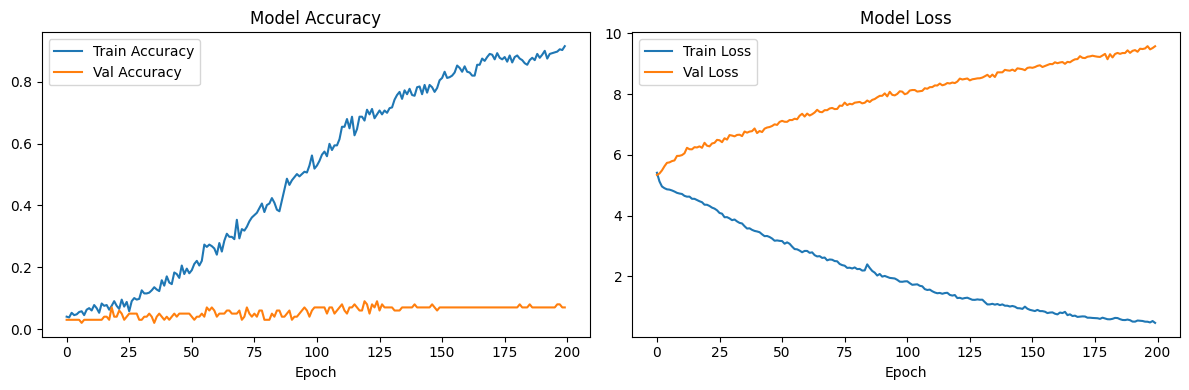

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_plot.png")
plt.show()

In [6]:
def predict_next_word(text, model, tokenizer, max_seq_len):
    token_list = tokenizer.texts_to_sequences([text.lower()])[0]
    token_list = pad_sequences([token_list],
                                maxlen=max_seq_len - 1,
                                padding='pre')
    predicted = model.predict(token_list, verbose=0)
    predicted_index = np.argmax(predicted)
    for word, index in tokenizer.word_index.items():
        if index == predicted_index:
            return word
    return ""

# Test predictions
test_sentences = [
    "to be or not",
    "the best time to",
    "life is what",
    "the mind is",
    "you only live",
]

print("── Next Word Predictions ──")
for sentence in test_sentences:
    next_word = predict_next_word(sentence, model, tokenizer, max_seq_len)
    print(f"  '{sentence}' → '{next_word}'")

# Save model and tokenizer
model.save("movie_quotes_bilstm.h5")
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
print("\nModel and tokenizer saved!")

── Next Word Predictions ──
  'to be or not' → 'to'
  'the best time to' → 'plant'


  'life is what' → 'happens'
  'the mind is' → 'not'
  'you only live' → 'once'

Model and tokenizer saved!
